In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,losses,Model
from random import randint

In [5]:
(X_train,Y_Train),(X_test,Y_test) = (tf.keras.datasets.mnist.load_data())


In [6]:
# desiging encoder model
input_layer = layers.Input(shape=X_train.shape[1:])
flattened  = layers.Flatten()(input_layer)
hidden = layers.Dense(100,activation='relu')(flattened)
latent  = layers.Dense(20,activation='relu')(hidden)


# encoder
encoder =  Model(
    inputs=input_layer,
    outputs=latent,
    name = 'encoder'
    )

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,520 (314.53 KB)

 Trainable params: 80,520 (314.53 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# designing decoder model

input_layer_decoder = layers.Input(shape=encoder.output.shape[1:])
upsampled = layers.Dense(100 ,activation='relu')(input_layer_decoder)
Upsampled = layers.Dense(784,activation='relu')(upsampled)
constructed_image = layers.Reshape(X_train.shape[1:])(Upsampled)


decoder = Model(
    inputs = input_layer_decoder,
    outputs = constructed_image,
    name = 'decoder'
    )

decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        79,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,284 (317.52 KB)

 Trainable params: 81,284 (317.52 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# designing Auto encoder

autoencoder =  Model(inputs= encoder.input,outputs = decoder(encoder.output) ,name = 'Autoencoder')

autoencoder.summary()
autoencoder.compile(
    optimizer = 'adam',
    loss = losses.MeanSquaredError(),
    metrics = ['accuracy']  
)

history = autoencoder.fit(X_train,X_train , epochs=30, batch_size = 32 , validation_data = (X_test,X_test))


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28)         │        81,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,804 (632.05 KB)

 Trainable params: 161,804 (632.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5264 - loss: 1449.6786 - val_accuracy: 0.5254 - val_loss: 1420.5354
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5295 - loss: 1429.5656 - val_accuracy: 0.5284 - val_loss: 1412.1187
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5318 - loss: 1415.6064 - val_accuracy: 0.5330 - val_loss: 1389.6989
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5339 - loss: 1403.7954 - val_accuracy: 0.5324 - val_loss: 1387.8307
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5353 - loss: 1367.8350 - val_accuracy: 0.5325 - val_loss: 1344.1132
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5366 - loss: 1357.9694 - val_accuracy: 0.5323 - val_loss: 1340.0912
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5369 - loss: 1348.3224 - val_accuracy: 0.5373 - val_loss: 1334.3868
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms

Text(0.5, 1.0, 'Accuracy plot')

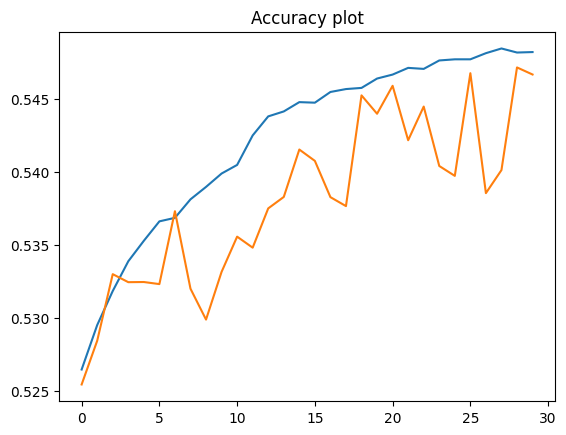

In [15]:
# accuracy and loss plot
plt.plot(history.history['accuracy'],label = 'train accuracy')
plt.plot(history.history['val_accuracy'],label = 'test accuracy')
plt.title('Accuracy plot')

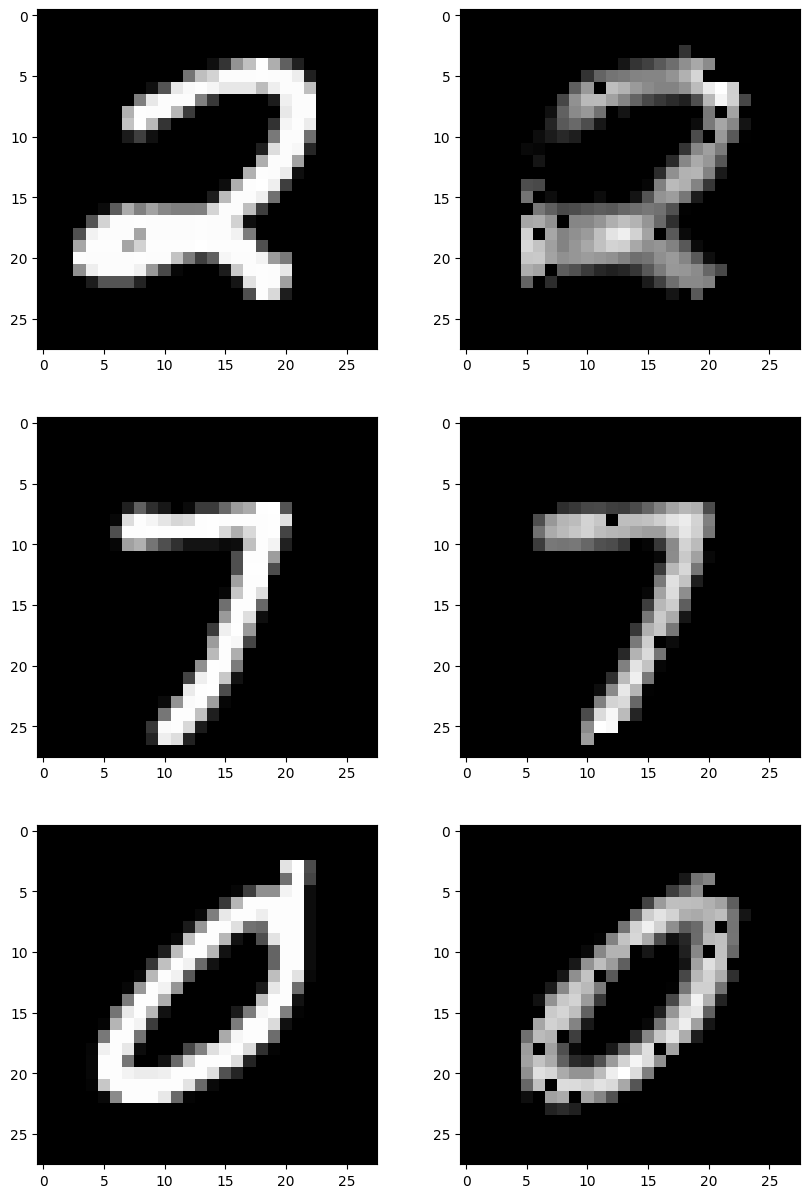

In [16]:
# taking random imagea and checking
fig,axs = plt.subplots(3,2,figsize = (10,15))
for i in range(3):
    sample = X_train[randint(0,X_train.shape[0])]
    axs[i,0].imshow(sample,cmap = 'gray')
    axs[i][1].imshow(autoencoder(np.expand_dims(sample,axis=0))[0],cmap = 'gray') # 1,28,28
plt.show()